# CS 6220 Homework 1: Iris Classification Pipeline

This notebook builds and evaluates a scikit-learn pipeline for predicting Iris flower species.

**Environment:** Python, VS Code, Jupyter Notebook, and scikit-learn  
**Dataset:** Iris dataset included with scikit-learn  
**Reproducibility:** `random_state = 42`

In [1]:
# Import standard libraries for timing and data analysis.
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Import the Iris dataset, modeling pipeline tools, and evaluation metrics.
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Make plots visually consistent.
sns.set_theme(style="whitegrid")

# Fixed seed makes the results reproducible.
RANDOM_STATE = 42

### Load and Inspect the Iris Dataset

The Iris dataset contains measurements for 150 flowers from three species: setosa, versicolor, and virginica. The goal is to predict each flower’s species from its four measurements.

In [2]:
# Load the Iris dataset from scikit-learn.
iris = load_iris(as_frame=True)

# Combine the input features and target class into one table for inspection.
iris_df = iris.frame.copy()
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

# Display the first five rows and basic dataset information.
print(f"Dataset shape: {iris_df.shape}")
print(f"Feature names: {list(iris.feature_names)}")
print(f"Class names: {list(iris.target_names)}")

iris_df.head()

Dataset shape: (150, 6)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Check Data Quality and Visualize Feature Relationships

Before training the model, verify that the dataset has no missing values. The scatterplot helps show how flower species differ by petal measurements.

Missing values by column:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

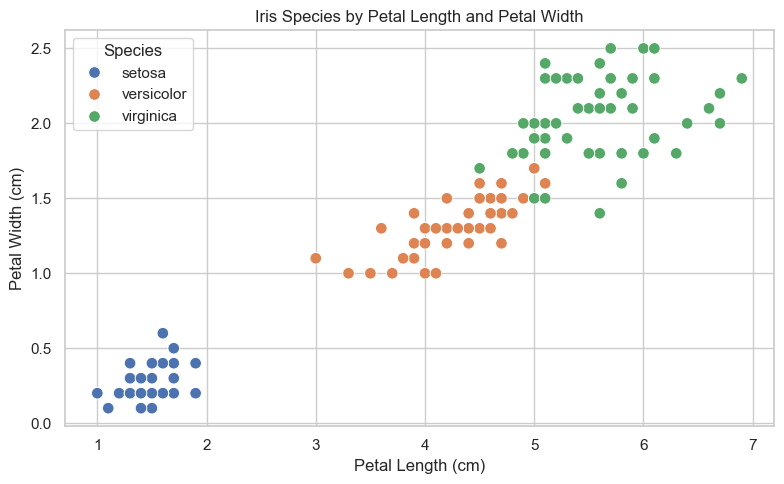

In [3]:
# Check for missing values in every column.
missing_values = iris_df.isna().sum()

print("Missing values by column:")
display(missing_values)

# Visualize two informative features: petal length and petal width.
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=iris_df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    palette="deep",
    s=70
)

plt.title("Iris Species by Petal Length and Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()

### Prepare Training and Test Data

The dataset is split into 80% training data and 20% testing data. Stratification preserves the proportion of each species in both sets.

In [4]:
# Define input features (X) and the species label to predict (y).
X = iris.data
y = iris.target

# Split the data: 80% for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Confirm the split sizes and class distributions.
print(f"Training examples: {X_train.shape[0]}")
print(f"Testing examples: {X_test.shape[0]}")

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training examples: 120
Testing examples: 30

Training class distribution:
target
0    40
1    40
2    40
Name: count, dtype: int64

Testing class distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


### Build the Scikit-Learn Pipeline

The pipeline standardizes feature values, then trains a logistic-regression classifier. Using a pipeline keeps preprocessing and modeling together, preventing data leakage and making the workflow easier to reproduce.

In [5]:
# Create a pipeline with feature scaling followed by logistic regression.
iris_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_000,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

# Display the pipeline structure.
iris_pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Train the Model and Measure Training Time

Training time is measured with `perf_counter()`, a high-resolution timer.

In [6]:
# Measure how long model training takes.
training_start_time = perf_counter()

iris_pipeline.fit(X_train, y_train)

training_end_time = perf_counter()
training_time_seconds = training_end_time - training_start_time

print(f"Training time: {training_time_seconds:.6f} seconds")

Training time: 0.014866 seconds


### Test the Model and Measure Testing Time

The trained pipeline predicts species for the held-out test data. Testing time includes generating predictions.

In [7]:
# Measure how long prediction on the test set takes.
testing_start_time = perf_counter()

y_pred = iris_pipeline.predict(X_test)

testing_end_time = perf_counter()
testing_time_seconds = testing_end_time - testing_start_time

print(f"Testing time: {testing_time_seconds:.6f} seconds")

Testing time: 0.002215 seconds


### Evaluate Test Accuracy

Accuracy is the proportion of test examples whose predicted species matches the true species.

In [8]:
# Calculate the model's prediction accuracy on the test data.
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 93.33%


### Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each Iris species.

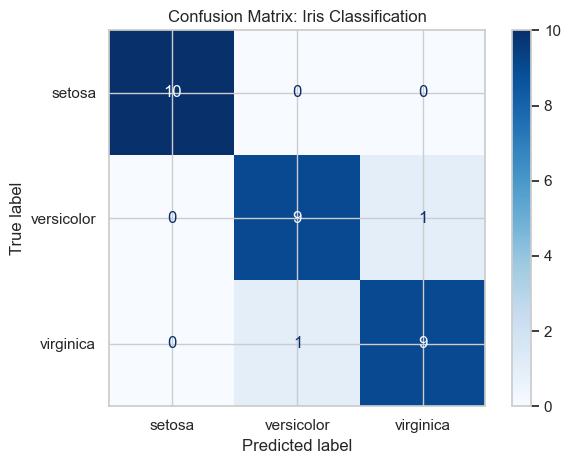

In [9]:
# Plot a confusion matrix for detailed evaluation by species.
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix: Iris Classification")
plt.tight_layout()
plt.show()

### Final Results

The table below summarizes the required measured results from the Iris classification pipeline.

In [10]:
# Summarize the required Homework 1 results in one table.
results_summary = pd.DataFrame(
    {
        "Metric": [
            "Training time (seconds)",
            "Testing time (seconds)",
            "Test accuracy",
        ],
        "Result": [
            f"{training_time_seconds:.6f}",
            f"{testing_time_seconds:.6f}",
            f"{test_accuracy:.2%}",
        ],
    }
)

results_summary

,Metric,Result
0,Training time (seconds),0.014866
1,Testing time (seconds),0.002215
2,Test accuracy,93.33%


### Optional: Hyperparameter Exploration

This experiment compares several values of the logistic-regression regularization parameter `C`. A higher `C` applies less regularization.

In [11]:
C_VALUES = [0.01, 0.1, 1.0, 10.0]

hyperparameter_results = []

for c_value in C_VALUES:
    candidate_pipeline = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    C=c_value,
                    max_iter=1_000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    candidate_pipeline.fit(X_train, y_train)
    candidate_predictions = candidate_pipeline.predict(X_test)
    candidate_accuracy = accuracy_score(y_test, candidate_predictions)

    hyperparameter_results.append(
        {
            "C value": c_value,
            "Test accuracy": candidate_accuracy,
        }
    )

hyperparameter_df = pd.DataFrame(hyperparameter_results)
hyperparameter_df["Test accuracy"] = hyperparameter_df["Test accuracy"].map(
    lambda value: f"{value:.2%}"
)

hyperparameter_df

,C value,Test accuracy
0,0.01,80.00%
1,0.10,86.67%
2,1.00,93.33%
3,10.00,100.00%


In the hyperparameter experiment, accuracy increased from 80.00% at `C=0.01` to 100.00% at `C=10.00`. For this particular train-test split, less regularization produced better test accuracy.

### Interpretation and Conclusion

The pipeline used `StandardScaler` followed by logistic regression to classify Iris flower species. The model was trained on 120 examples and evaluated on 30 held-out examples.

The measured training time, testing time, and test accuracy are shown in the final-results table above. The confusion matrix provides a class-by-class view of correct and incorrect predictions. The optional hyperparameter experiment shows whether changing the logistic-regression `C` value affected test accuracy for this split.

Because `random_state=42` and stratified splitting were used, the experiment is reproducible.